In [ ]:
%pip install pandas numpy seaborn matplotlib scipy pydeseq2 gprofiler scanpy
!rm -drf Data
!mkdir Data
!wget https://raw.githubusercontent.com/simonelsasser/SP1-01-Ex/f048b4557e63417354839094bf812fd808a67dde/Kumar_NCB/Data/metaData.csv -O Data/metaData.csv
!wget https://raw.githubusercontent.com/simonelsasser/SP1-01-Ex/f048b4557e63417354839094bf812fd808a67dde/Kumar_NCB/Data/rsem.merged.gene_counts_2021.tsv -O Data/rsem.merged.gene_counts_2021.tsv
!wget https://raw.githubusercontent.com/simonelsasser/SP1-01-Ex/f048b4557e63417354839094bf812fd808a67dde/Kumar_NCB/Data/gene_group_mapping.csv -O Data/gene_group_mapping.csv
!ls Data/
!cat Data/metaData.csv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


--2026-05-18 22:52:35--  https://raw.githubusercontent.com/simonelsasser/SP1-01-Ex/f048b4557e63417354839094bf812fd808a67dde/Kumar_NCB/Data/metaData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 633 [text/plain]
Saving to: ‘Data/metaData.csv’

Data/metaData.csv   100%[===================>]     633  --.-KB/s    in 0.001s  

2026-05-18 22:52:35 (1.19 MB/s) - ‘Data/metaData.csv’ saved [633/633]

--2026-05-18 22:52:35--  https://raw.githubusercontent.com/simonelsasser/SP1-01-Ex/f048b4557e63417354839094bf812fd808a67dde/Kumar_NCB/Data/rsem.merged.gene_counts_2021.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.1

In [2]:
import pandas as pd
import numpy as np

#########################
######   TASK 1   #######
#      read in data     #
#########################

file_path = "Data/rsem.merged.gene_counts_2021.tsv"
# Read in count file "Data/rsem.merged.gene_counts_2021.tsv", it is a tab-separated file with the first column as index
count_table = pd.read_csv(file_path, sep='\t', index_col=0)
# Print the first 5 rows of the count table
print(count_table.head())

                                           transcript_id(s)  Naive_EZH2i_R1  \
gene_id                                                                       
A1BG                                              NM_130786             3.0   
A1BG-AS1                                          NR_015380             7.0   
A1CF      NM_001198818,NM_001198819,NM_001198820,NM_0145...             0.0   
A2M                                               NM_000014             1.0   
A2M-AS1                                           NR_026971             0.0   

          Naive_EZH2i_R2  Naive_EZH2i_R3  Naive_R1  Naive_R2  Naive_R3  \
gene_id                                                                  
A1BG                 4.0             6.0       2.0       0.0       4.0   
A1BG-AS1             4.0             5.0       2.0       3.0       2.0   
A1CF                 0.0             0.0       0.0       0.0       0.0   
A2M                  1.0             1.0       0.0       0.0       0.0   
A2

In [3]:

# we are going to remove 'transcript_id(s)' from the count table, as they are not needed for the analysis
count_table = count_table.drop('transcript_id(s)', axis=1)
# Print the head again
print(count_table.head())


          Naive_EZH2i_R1  Naive_EZH2i_R2  Naive_EZH2i_R3  Naive_R1  Naive_R2  \
gene_id                                                                        
A1BG                 3.0             4.0             6.0       2.0       0.0   
A1BG-AS1             7.0             4.0             5.0       2.0       3.0   
A1CF                 0.0             0.0             0.0       0.0       0.0   
A2M                  1.0             1.0             1.0       0.0       0.0   
A2M-AS1              0.0             0.0             0.0       0.0       0.0   

          Naive_R3  Primed_EZH2i_R1  Primed_EZH2i_R2  Primed_EZH2i_R3  \
gene_id                                                                 
A1BG           4.0            137.0            175.0            143.0   
A1BG-AS1       2.0             36.0             28.0             28.0   
A1CF           0.0              2.0              0.0              0.0   
A2M            0.0            143.0            114.0            112.0   
A

In [4]:
# Read in file 
experiment_design = pd.read_csv("Data/metaData.csv", sep=",")

# Get an overview of the file
print(experiment_design)

       BioSample          SRR condition treatment             Name
0   SAMN25076933  SRR17657871     naive      none         Naive_R1
1   SAMN25076934  SRR17657872     naive      none         Naive_R2
2   SAMN25076935  SRR17657873     naive      none         Naive_R3
3   SAMN25076936  SRR17657874     naive     EZH2i   Naive_EZH2i_R1
4   SAMN25076938  SRR17657875     naive     EZH2i   Naive_EZH2i_R2
5   SAMN25076939  SRR17657876     naive     EZH2i   Naive_EZH2i_R3
6   SAMN25076940  SRR17657877    primed      none        Primed_R1
7   SAMN25076941  SRR17657878    primed      none        Primed_R2
8   SAMN25076942  SRR17657879    primed      none        Primed_R3
9   SAMN25076943  SRR17657880    primed     EZH2i  Primed_EZH2i_R1
10  SAMN25076944  SRR17657881    primed     EZH2i  Primed_EZH2i_R2
11  SAMN25076945  SRR17657882    primed     EZH2i  Primed_EZH2i_R3


In [5]:
#########################
######   TASK 2   #######
# Preparation for DESeq #
#########################

# prepare metaData
# shape meta for DESeq analysis (name as index, treatment and condition as column)
meta = experiment_design.set_index("Name")
#meta = meta[["treatment","condition"]]
# shape meta for DESeq analysis (name as index, treatment and condition as column)
# add a column "design" that is a combination of treatment and condition, e.g. "Naive_EZH2i" and "Primed_EZH2i"
meta["design"] = meta["condition"] + "_" + meta["treatment"]
print(meta)

                    BioSample          SRR condition treatment        design
Name                                                                        
Naive_R1         SAMN25076933  SRR17657871     naive      none    naive_none
Naive_R2         SAMN25076934  SRR17657872     naive      none    naive_none
Naive_R3         SAMN25076935  SRR17657873     naive      none    naive_none
Naive_EZH2i_R1   SAMN25076936  SRR17657874     naive     EZH2i   naive_EZH2i
Naive_EZH2i_R2   SAMN25076938  SRR17657875     naive     EZH2i   naive_EZH2i
Naive_EZH2i_R3   SAMN25076939  SRR17657876     naive     EZH2i   naive_EZH2i
Primed_R1        SAMN25076940  SRR17657877    primed      none   primed_none
Primed_R2        SAMN25076941  SRR17657878    primed      none   primed_none
Primed_R3        SAMN25076942  SRR17657879    primed      none   primed_none
Primed_EZH2i_R1  SAMN25076943  SRR17657880    primed     EZH2i  primed_EZH2i
Primed_EZH2i_R2  SAMN25076944  SRR17657881    primed     EZH2i  primed_EZH2i

In [6]:
# prepare count table 
# filter for lowly expressed genes
genes_to_keep = count_table.columns[count_table.sum(axis=0) >= 10]
counts_df = count_table[genes_to_keep]

# convert dataframe to integer
counts_df = counts_df.astype(int)

# transpose dataframe for Deseq analysis
counts_df = counts_df.T

# tricky part: make sure that the order of samples in the count table matches the order of samples in the meta data, otherwise DESeq2 will throw an error. 
# We can do this by reindexing the count table with the index of the meta data.
print(counts_df.index)
counts_df = counts_df.loc[meta.index]
print(counts_df.index)

Index(['Naive_EZH2i_R1', 'Naive_EZH2i_R2', 'Naive_EZH2i_R3', 'Naive_R1',
       'Naive_R2', 'Naive_R3', 'Primed_EZH2i_R1', 'Primed_EZH2i_R2',
       'Primed_EZH2i_R3', 'Primed_R1', 'Primed_R2', 'Primed_R3'],
      dtype='object')
Index(['Naive_R1', 'Naive_R2', 'Naive_R3', 'Naive_EZH2i_R1', 'Naive_EZH2i_R2',
       'Naive_EZH2i_R3', 'Primed_R1', 'Primed_R2', 'Primed_R3',
       'Primed_EZH2i_R1', 'Primed_EZH2i_R2', 'Primed_EZH2i_R3'],
      dtype='object', name='Name')


In [8]:
#######################
######   TASK 3   #######
#     Running DESeq2    #
#########################

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DeseqDataSet
dds = DeseqDataSet(
    counts=counts_df,
    metadata=meta,
    design="~design",
    refit_cooks=True)


In [9]:
# run dds.deseq2()
dds.deseq2()

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 31.56 seconds.

Fitting dispersion trend curve...
... done in 0.64 seconds.

Fitting MAP dispersions...
... done in 30.60 seconds.

Fitting LFCs...
... done in 18.03 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 0 outlier genes.



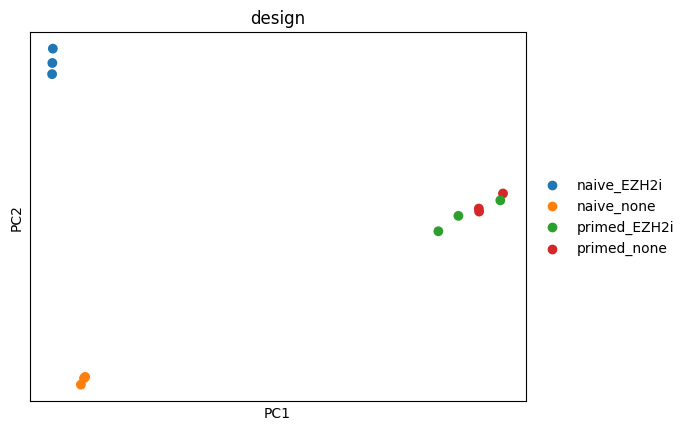

In [ ]:
#extract and log transform the normalized counts for PCA, it is stored in dds.layers["normed_counts"], a samples x genes matrix

import scanpy as sc

sc.tl.pca(dds)
sc.pl.pca(dds, color="design", size=200,title="PCA of normalized counts")

In [ ]:
# Extract the results of the DESeq2 analysis for the contrast "Naive_EZH2i" vs "Naive_none", which is then
# stored in the "results_df" attribute of the ds object

ds = DeseqStats(dds, contrast=["design", "naive_EZH2i", "naive_none"], n_cpus=1)
EZH2i_vs_naive_raw_lfc = ds.results_df["log2FoldChange"].copy()
ds.lfc_shrink(coeff="design[T.naive_none]")

EZH2i_vs_naive = ds.results_df
ds.summary()


Running Wald tests...
... done in 6.23 seconds.



Log2 fold change & Wald test p-value: design naive_EZH2i vs naive_none
             baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_id                                                                    
A1BG        30.878081        1.605420  0.735297   2.183363  2.900907e-02   
A1BG-AS1    10.796228        1.682458  0.702650   2.394446  1.664551e-02   
A1CF         0.164028        0.489783  4.918717   0.099575  9.206815e-01   
A2M         26.315026        2.932455  2.122058   1.381892  1.670050e-01   
A2M-AS1      1.510204        0.489794  2.843867   0.172228  8.632581e-01   
...               ...             ...       ...        ...           ...   
ZYG11A     159.035116       -2.108800  0.182161 -11.576604  5.414878e-31   
ZYG11B     281.050682        0.194481  0.132526   1.467490  1.422429e-01   
ZYX       2183.877283       -0.018819  0.103489  -0.181849  8.557012e-01   
ZZEF1      450.410347       -0.273564  0.092560  -2.955523  3.121392e-03   
ZZZ3       331.01

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: design[T.naive_none]
             baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_id                                                                    
A1BG        30.878081       -1.070979  0.722766   2.183363  2.900907e-02   
A1BG-AS1    10.796228       -1.209334  0.714400   2.394446  1.664551e-02   
A1CF         0.164028       -0.008115  0.594739   0.099575  9.206815e-01   
A2M         26.315026       -0.697561  0.990770   1.381892  1.670050e-01   
A2M-AS1      1.510204       -0.011466  0.572472   0.172228  8.632581e-01   
...               ...             ...       ...        ...           ...   
ZYG11A     159.035116        2.083389  0.182909 -11.576604  5.414878e-31   
ZYG11B     281.050682       -0.187612  0.129339   1.467490  1.422429e-01   
ZYX       2183.877283        0.018227  0.101794  -0.181849  8.557012e-01   
ZZEF1      450.410347        0.269230  0.091517  -2.955523  3.121392e-03   
ZZZ3       331.013195 

... done in 73.01 seconds.



In [21]:
# genes to mark as in volcanoe plot
genes_3a =  ["KRT18",  "H19", "IGF2", "EPAS2", "COL6A3", "MME",
    "VIM", "MMP2", "EGFL6", "CCKBR", "GATA2", "COL15A1", "CD99","EPAS1",
    "LAMB1", "THBD", "FRZB",  "RELN", "TDGF1", "MT1G","DDPA5","NODAL","NANOG","UTF1",
    "FGF4"]


#######
# Volcano plot:
# xaxis is the log2 fold change, yaxis is the -log10 of the adjusted p-value

#print Volcano plot plot of the results, color points with padj < 0.05 and |lfc|>1 in red and the rest in black
plt.figure(figsize=(10, 7))
colors = np.where((EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] > 1), "blue", np.where((EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] < -1), "red", "black"))
plt.scatter(EZH2i_vs_naive["log2FoldChange"], -np.log10(EZH2i_vs_naive["padj"]), c=colors, alpha=0.5, s=4)
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Volcano Plot of DESeq2 Results")

# Add text labels for genes in genes_2e
texts = []
for gene in genes_3a:
    if gene in EZH2i_vs_naive.index:
        x = EZH2i_vs_naive.loc[gene, "log2FoldChange"]
        y = -np.log10(EZH2i_vs_naive.loc[gene, "padj"])
        texts.append(plt.text(x, y, gene, fontsize=8))
plt.show()

NameError: name 'plt' is not defined

In [63]:

topEZH2i = EZH2i_vs_naive[(EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] < -5)]

#from normed_counts_long, subset for the genes in genes_2e and plot a heatmap of the normalized counts for these genes across the samples, group by design
normed_counts_3a = normed_counts_log[normed_counts_log["gene_id"].isin(topEZH2i.index.tolist())]
normed_counts_3a_pivot = normed_counts_3a.pivot(index="gene_id", columns="Name", values="normalized_count")

# sort columns by design order: naive_none, naive_EZH2i, primed_none, primed_EZH2i
design_order = ["naive_none","naive_EZH2i","primed_none","primed_EZH2i"]
sorted_columns = sorted(normed_counts_3a_pivot.columns, 
                       key=lambda x: (design_order.index(meta.loc[x, "design"]), x))
normed_counts_3a_pivot = normed_counts_3a_pivot[sorted_columns]
# plot a heatmap of the normalized counts for these genes across the samples, group by design
plt.figure(figsize=(4, 8))
sns.heatmap(normed_counts_3a_pivot, cmap="viridis", yticklabels=True)
plt.title("Heatmap of Normalized Counts for Genes most significantly upregulated in EZH2i vs naive")
plt.xlabel("Sample")
plt.ylabel("Gene")
plt.xticks(rotation=90)
plt.show()

In [ ]:
#######
# GENE SET ENRICHMENT ANALYSIS
# get naive- and primed-specific genes-sets 

sigUp = EZH2i_vs_naive[(EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] > 2)]

# get significantly downregulated genes
sigDown = EZH2i_vs_naive[(EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] < -2)]

# perform gene set enrichment analysis with gprofiler for the upregulated genes, use the "gost" function and specify the organism as "hsapiens"
from gprofiler.gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)

enrichment_up = gp.profile(query=sigUp.index.tolist(), organism="hsapiens")
enrichment_down = gp.profile(query=sigDown.index.tolist(), organism="hsapiens")

###
print(enrichment_up.head())

In [ ]:
print(enrichment_down.head())
